In [1]:
import numpy as np
import pandas as pd
file_path = "../Dataset/XAU.csv"
df = pd.read_csv(file_path)
df.shape
bc = df.copy()

Preprocessing

In [91]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(data, target, test_size=0.2)

In [92]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((5691, 14), (1423, 14), (5691,), (1423,))

In [93]:
x_train

,datetime,close,high,low,open,volume,Tenkan_sen,Kijun_sen,Senkou_Span_A,Senkou_Span_B,Chikou_Span,EMA12,EMA26,MACD
6,1014202540600,4178.299805,4178.899902,4178.000000,4178.200195,117,NaN,NaN,NaN,NaN,4176.299805,4176.354947,4175.684569,0.670378
2707,1016202540900,4248.600098,4248.899902,4247.100098,4247.200195,106,4247.100098,4247.100098,4246.674927,4248.649902,4252.000000,4248.004702,4247.928650,0.076053
4849,1017202551900,4215.600098,4215.700195,4212.500000,4215.700195,327,4211.600098,4210.699951,4226.150025,4237.800049,4232.299805,4213.338073,4214.527588,-1.189515
2793,1016202553500,4222.100098,4223.600098,4220.000000,4222.000000,511,4226.849854,4232.050049,4244.650024,4246.950195,4222.600098,4228.055528,4233.461277,-5.405748
5789,10202025102000,4267.899902,4268.399902,4266.600098,4268.399902,89,4266.100098,4268.699951,4273.275024,4271.449951,4272.500000,4268.149490,4268.739254,-0.589765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
750,1014202552000,4160.700195,4162.200195,4157.700195,4158.500000,285,4161.350098,4160.750000,4162.050049,4158.300049,4160.600098,4160.916583,4161.280079,-0.363497
5168,10192025114000,4258.700195,4260.200195,4258.700195,4259.600098,46,4258.899902,4257.399902,4263.824951,4266.199952,4246.600098,4258.800049,4259.544876,-0.744827
6488,10202025105900,4385.299805,4385.299805,4383.399902,4383.399902,32,4385.599854,4381.750000,4386.150147,4381.900147,4382.000000,4384.596522,4384.105399,0.491123
4182,1017202560300,4377.000000,4377.700195,4375.100098,4377.200195,231,4378.699952,4373.799805,4365.799927,4371.949951,4374.200195,4378.128813,4376.726178,1.402635


In [94]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_train

array([[3.32687433e-09, 2.43177558e-01, 2.39500092e-01, ...,
        2.20908576e-01, 2.06037841e-01, 6.39056463e-01],
       [2.17446126e-04, 4.86011040e-01, 4.82471200e-01, ...,
        4.79260569e-01, 4.74395297e-01, 6.13725781e-01],
       [3.26168706e-04, 3.72021402e-01, 3.67234492e-01, ...,
        3.54260942e-01, 3.50323900e-01, 5.59786145e-01],
       ...,
       [9.98912784e-01, 9.58203465e-01, 9.55917422e-01, ...,
        9.71778217e-01, 9.80236683e-01, 6.31416443e-01],
       [3.26169619e-04, 9.29534017e-01, 9.29539056e-01, ...,
        9.48457195e-01, 9.52825870e-01, 6.70265925e-01],
       [3.90309766e-09, 2.52504656e-01, 2.50608023e-01, ...,
        2.36182878e-01, 2.18369544e-01, 6.78109275e-01]], shape=(5691, 14))

In [95]:
x_test

array([[1.08722927e-04, 3.70984121e-01, 3.67234492e-01, ...,
        3.66270564e-01, 3.65204640e-01, 5.31002307e-01],
       [1.16331880e-09, 1.15370995e-01, 1.12808014e-01, ...,
        9.28128902e-02, 6.85057418e-02, 7.02967564e-01],
       [3.26166629e-04, 5.20207592e-01, 5.18569428e-01, ...,
        5.05596971e-01, 5.11089576e-01, 5.04001110e-01],
       ...,
       [6.52336031e-04, 9.40242473e-01, 9.37869157e-01, ...,
        9.65586669e-01, 9.83150949e-01, 5.24792972e-01],
       [1.08730560e-04, 3.45768905e-01, 3.46060958e-01, ...,
        3.32356887e-01, 3.28160821e-01, 5.55172510e-01],
       [2.17450399e-04, 4.81865285e-01, 4.86637099e-01, ...,
        4.68742881e-01, 4.61512356e-01, 6.37222019e-01]], shape=(1423, 14))

# Classification

In [96]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score
def calculate_metrics(y_train, y_test, y_pred_train, y_pred_test):
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    per = precision_score(y_test, y_pred_test, average='macro')
    rec = recall_score(y_test, y_pred_test, average='macro')
    print(f"acc_train:{acc_train:.4f}, acc_test:{acc_test:.4f}, precision:{per:.4f}, recall:{rec:.4f}")
    return acc_train, acc_test, per, rec




4. Random forest

In [97]:
from sklearn.ensemble import RandomForestClassifier
forest = RandomForestClassifier(n_estimators=1000,max_depth=32,min_samples_split=8)


forest.fit(x_train, y_train)
y_pred_train = forest.predict(x_train)
y_pred_test = forest.predict(x_test)
acc_train_forest, acc_test_forest, per_forest, rec_forest = calculate_metrics(y_train, y_test, y_pred_train, y_pred_test)

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC

model = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler(),
    SVC(kernel='poly')
)

model.fit(x_train, y_train)
y_pred = model.predict(x_test)


C:\Users\me.soleymani\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


acc_train:0.9733, acc_test:0.9733, precision:0.3244, recall:0.3333


5. SVM

In [98]:
from sklearn.svm import SVC
svm = SVC(kernel='poly')
svm.fit(x_train, y_train)
y_pred_train = svm.predict(x_train)
y_pred_test = svm.predict(x_test)
acc_train_svm, acc_test_svm, per_svm, rec_svm = calculate_metrics(y_train, y_test, y_pred_train, y_pred_test)

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC

svm_pipeline = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler(),
    SVC(kernel='poly')
)

svm_pipeline.fit(x_train, y_train)
y_pred = svm_pipeline.predict(x_test)


ValueError: Input X contains NaN.
SVC does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

7. ANN

In [75]:
from sklearn.neural_network import MLPClassifier
ann = MLPClassifier(hidden_layer_sizes=1024, activation='relu',solver='adam')
ann.fit(x_train, y_train)
y_pred_train = ann.predict(x_train)
y_pred_test = ann.predict(x_test)
acc_train_ann, acc_test_ann, per_ann, rec_ann = calculate_metrics(y_train, y_test, y_pred_train, y_pred_test)

ValueError: Input X contains NaN.
MLPClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

Comparison

In [76]:
import matplotlib.pyplot as plt
acc_train = [acc_train_forest, acc_train_ann, acc_train_svm]
title = ["Forest","ANN","SVM"]
plt.grid()
plt.bar(title, acc_train)

NameError: name 'acc_train_forest' is not defined

<BarContainer object of 7 artists>

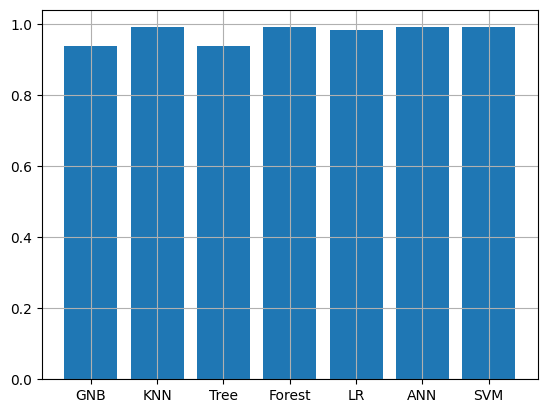

In [151]:
acc_test = [acc_test_forest, acc_test_ann, acc_test_svm]
title = ["Forest","ANN","SVM"]
plt.grid()
plt.bar(title, acc_test)

<BarContainer object of 7 artists>

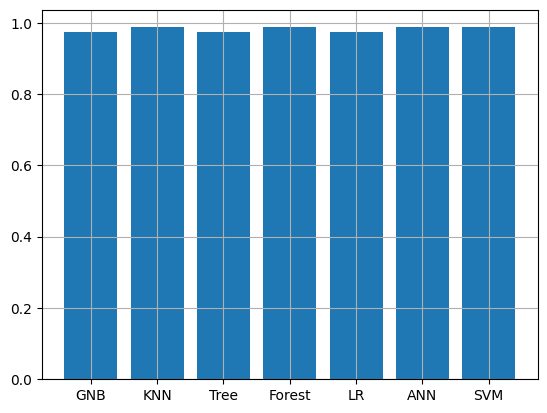

In [152]:
per = [per_forest, per_ann, per_svm]
title = ["Forest","ANN","SVM"]
plt.grid()
plt.bar(title, per)

<BarContainer object of 7 artists>

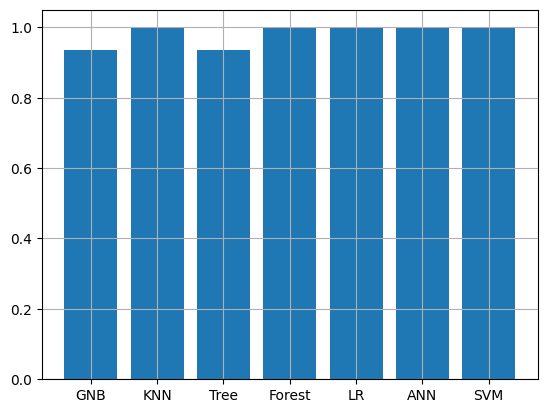

In [153]:
rec = [ rec_forest, rec_ann, rec_svm]
title = ["Forest","ANN","SVM"]
plt.grid()
plt.bar(title, rec)